Playing with Minimax...
AI (Minimax) expanded 3999675 nodes, Max depth reached: 5
Time taken for AI move: 45.1781 seconds
AI (Minimax) expanded 1404685 nodes, Max depth reached: 5
Time taken for AI move: 18.0541 seconds
AI (Minimax) expanded 375799 nodes, Max depth reached: 5
Time taken for AI move: 6.4612 seconds
AI (Minimax) expanded 53693 nodes, Max depth reached: 5
O wins!
Time taken for AI move: 1.2607 seconds

Playing with Alpha-Beta Pruning...
AI (Alpha-Beta) expanded 137361 nodes, Max depth reached: 5
Time taken for AI move: 2.4534 seconds
AI (Alpha-Beta) expanded 97678 nodes, Max depth reached: 5
Time taken for AI move: 1.6634 seconds
AI (Alpha-Beta) expanded 64167 nodes, Max depth reached: 5
Time taken for AI move: 1.1568 seconds
AI (Alpha-Beta) expanded 19422 nodes, Max depth reached: 5
Time taken for AI move: 0.4937 seconds
AI (Alpha-Beta) expanded 3500 nodes, Max depth reached: 5
Time taken for AI move: 0.1296 seconds
AI (Alpha-Beta) expanded 262 nodes, Max depth reached: 

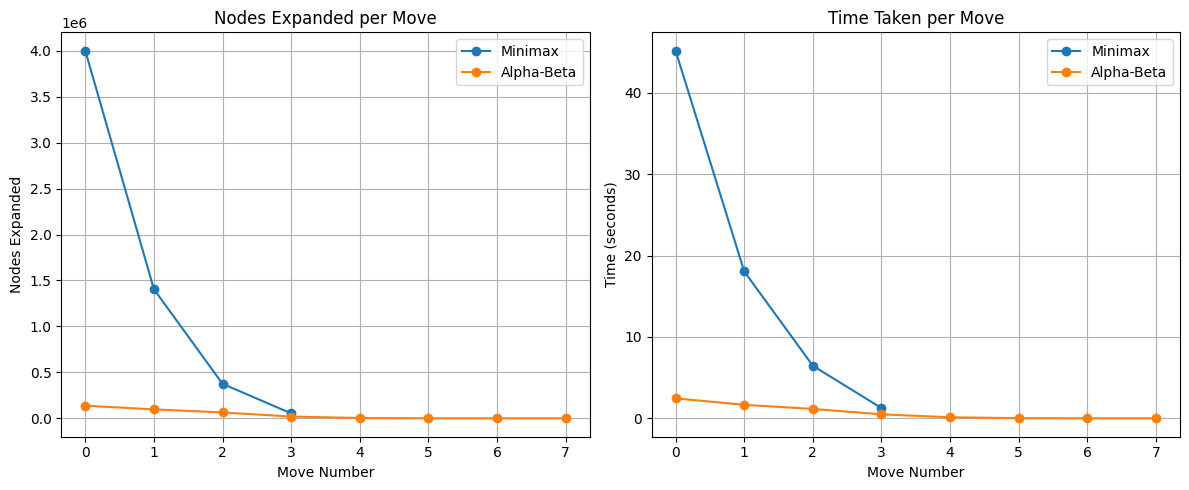

In [6]:
import numpy as np
import pygame
import sys
import random
import time
import matplotlib.pyplot as plt
pygame.init()

WIDTH, HEIGHT = 600, 600
LINE_WIDTH = 10
BOARD_ROWS, BOARD_COLS = 4, 4
CELL_SIZE = WIDTH // BOARD_COLS
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
RED = (255, 0, 0)
MAX_DEPTH = 5

def timer(func):
    def wrapper(self, *args, **kwargs):
        start_time = time.time()
        result = func(self, *args, **kwargs)
        end_time = time.time()
        elapsed_time = end_time - start_time
        if self.use_alphabeta:
            self.alphabeta_times.append(elapsed_time)
        else:
            self.minimax_times.append(elapsed_time)
        print(f"Time taken for AI move: {elapsed_time:.4f} seconds")
        return result
    return wrapper

class TicTacToe:
    def __init__(self):
        self.board = np.full((4, 4), '-')
        self.current_player = 'X'
        self.window = pygame.display.set_mode((WIDTH, HEIGHT))
        pygame.display.set_caption("Tic-Tac-Toe 4x4")
        self.window.fill(WHITE)
        self.draw_grid()
        self.node_count = 0
        self.max_depth_reached = 0
        self.minimax_nodes = []
        self.minimax_times = []
        self.alphabeta_nodes = []
        self.alphabeta_times = []
        self.use_alphabeta = False

    def draw_grid(self):
        for row in range(1, BOARD_ROWS):
            pygame.draw.line(self.window, BLACK, (0, row * CELL_SIZE), (WIDTH, row * CELL_SIZE), LINE_WIDTH)
        for col in range(1, BOARD_COLS):
            pygame.draw.line(self.window, BLACK, (col * CELL_SIZE, 0), (col * CELL_SIZE, HEIGHT), LINE_WIDTH)
        pygame.display.update()

    def draw_move(self, row, col):
        center_x = col * CELL_SIZE + CELL_SIZE // 2
        center_y = row * CELL_SIZE + CELL_SIZE // 2
        if self.current_player == 'X':
            pygame.draw.line(self.window, RED, (center_x - 50, center_y - 50), (center_x + 50, center_y + 50), LINE_WIDTH)
            pygame.draw.line(self.window, RED, (center_x + 50, center_y - 50), (center_x - 50, center_y + 50), LINE_WIDTH)
        else:
            pygame.draw.circle(self.window, BLACK, (center_x, center_y), 50, LINE_WIDTH)
        pygame.display.update()

    def make_move(self, row, col):
        if self.board[row, col] == '-':
            self.board[row, col] = self.current_player
            self.draw_move(row, col)
            if self.is_winner(self.current_player):
                print(f"{self.current_player} wins!")
                return True
            if self.is_full():
                print("It's a tie!")
                return True
            self.current_player = 'O' if self.current_player == 'X' else 'X'
            return False

    def is_winner(self, player):
        for row in self.board:
            if all(cell == player for cell in row):
                return True
        for col in range(4):
            if all(self.board[row][col] == player for row in range(4)):
                return True
        if all(self.board[i][i] == player for i in range(4)) or all(self.board[i][3 - i] == player for i in range(4)):
            return True
        return False

    def is_full(self):
        return '-' not in self.board

    def minimax(self, depth, is_maximizing):
        self.node_count += 1
        self.max_depth_reached = max(self.max_depth_reached, depth)
        if depth >= MAX_DEPTH:
            return 0
        if self.is_winner('O'):
            return 1
        if self.is_winner('X'):
            return -1
        if self.is_full():
            return 0
        best_score = float('-inf') if is_maximizing else float('inf')
        for i in range(4):
            for j in range(4):
                if self.board[i, j] == '-':
                    self.board[i, j] = 'O' if is_maximizing else 'X'
                    score = self.minimax(depth + 1, not is_maximizing)
                    self.board[i, j] = '-'
                    if is_maximizing:
                        best_score = max(best_score, score)
                    else:
                        best_score = min(best_score, score)
        return best_score

    def alpha_beta(self, depth, alpha, beta, is_maximizing):
        self.node_count += 1
        self.max_depth_reached = max(self.max_depth_reached, depth)
        if depth >= MAX_DEPTH:
            return 0
        if self.is_winner('O'):
            return 1
        if self.is_winner('X'):
            return -1
        if self.is_full():
            return 0
        if is_maximizing:
            best_score = float('-inf')
            for i in range(4):
                for j in range(4):
                    if self.board[i, j] == '-':
                        self.board[i, j] = 'O'
                        score = self.alpha_beta(depth + 1, alpha, beta, False)
                        self.board[i, j] = '-'
                        best_score = max(best_score, score)
                        alpha = max(alpha, score)
                        if beta <= alpha:
                            break
            return best_score
        else:
            best_score = float('inf')
            for i in range(4):
                for j in range(4):
                    if self.board[i, j] == '-':
                        self.board[i, j] = 'X'
                        score = self.alpha_beta(depth + 1, alpha, beta, True)
                        self.board[i, j] = '-'
                        best_score = min(best_score, score)
                        beta = min(beta, score)
                        if beta <= alpha:
                            break
            return best_score

    @timer
    def best_move(self):
        self.node_count = 0
        self.max_depth_reached = 0
        best_score = float('-inf')
        best_moves = []
        if not self.use_alphabeta:
            for i in range(4):
                for j in range(4):
                    if self.board[i, j] == '-':
                        self.board[i, j] = 'O'
                        score = self.minimax(0, False)
                        self.board[i, j] = '-'
                        if score > best_score:
                            best_score = score
                            best_moves = [(i, j)]
                        elif score == best_score:
                            best_moves.append((i, j))
            self.minimax_nodes.append(self.node_count)
        else:
            for i in range(4):
                for j in range(4):
                    if self.board[i, j] == '-':
                        self.board[i, j] = 'O'
                        score = self.alpha_beta(0, float('-inf'), float('inf'), False)
                        self.board[i, j] = '-'
                        if score > best_score:
                            best_score = score
                            best_moves = [(i, j)]
                        elif score == best_score:
                            best_moves.append((i, j))
            self.alphabeta_nodes.append(self.node_count)
        if best_moves:
            move = random.choice(best_moves)
        algo_name = "Alpha-Beta" if self.use_alphabeta else "Minimax"
        print(f"AI ({algo_name}) expanded {self.node_count} nodes, Max depth reached: {self.max_depth_reached}")
        self.make_move(move[0], move[1])

    def show_comparison(self, minimax_nodes, minimax_times, alphabeta_nodes, alphabeta_times):
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(minimax_nodes, label='Minimax', marker='o')
        plt.plot(alphabeta_nodes, label='Alpha-Beta', marker='o')
        plt.xlabel('Move Number')
        plt.ylabel('Nodes Expanded')
        plt.title('Nodes Expanded per Move')
        plt.legend()
        plt.grid(True)
        plt.subplot(1, 2, 2)
        plt.plot(minimax_times, label='Minimax', marker='o')
        plt.plot(alphabeta_times, label='Alpha-Beta', marker='o')
        plt.xlabel('Move Number')
        plt.ylabel('Time (seconds)')
        plt.title('Time Taken per Move')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def play_game(game):
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            if event.type == pygame.MOUSEBUTTONDOWN and game.current_player == 'X':
                x, y = event.pos
                row = y // CELL_SIZE
                col = x // CELL_SIZE
                if game.board[row, col] == '-':
                    if game.make_move(row, col):
                        running = False
        if game.current_player == 'O' and running:
            game.best_move()
            if game.is_winner('O') or game.is_full():
                running = False
    return game.minimax_nodes, game.minimax_times, game.alphabeta_nodes, game.alphabeta_times

if __name__ == "__main__":
    # First game with Minimax
    print("Playing with Minimax...")
    game1 = TicTacToe()
    minimax_nodes, minimax_times, _, _ = play_game(game1)
    pygame.quit()
    # Second game with Alpha-Beta
    pygame.init()
    print("\nPlaying with Alpha-Beta Pruning...")
    game2 = TicTacToe()
    game2.use_alphabeta = True
    _, _, alphabeta_nodes, alphabeta_times = play_game(game2)
    pygame.quit()
    # Show combined comparison
    game1.show_comparison(minimax_nodes, minimax_times, alphabeta_nodes, alphabeta_times)

# checkkers game

In [ ]:
import numpy as np
import pygame
import sys
import time
import matplotlib.pyplot as plt

# Initialize pygame
pygame.init()

# Constants for graphics
WIDTH, HEIGHT = 600, 600
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
RED = (255, 0, 0)
BLUE = (0, 0, 255)
CELL_SIZE = WIDTH // 8
KING_RED = (200, 0, 0)
KING_BLUE = (0, 0, 200)

class Checkers:
    def __init__(self, use_alpha_beta=False):
        self.board = self.create_board()
        self.window = pygame.display.set_mode((WIDTH, HEIGHT))
        self.use_alpha_beta = use_alpha_beta
        caption = "Checkers - Human (Red) vs AI (Blue) - " + ("Alpha-Beta" if use_alpha_beta else "Minimax")
        pygame.display.set_caption(caption)
        self.selected_piece = None
        self.current_player = 'R'
        self.depth_limit = 4
        self.draw_board()
        self.move_history = []
        self.ai_metrics = [] # (time_taken, nodes_expanded, depth)

    def create_board(self):
        board = np.full((8, 8), '-')
        for row in range(3):
            for col in range(8):
                if (row + col) % 2 == 1:
                    board[row][col] = 'B'
        for row in range(5, 8):
            for col in range(8):
                if (row + col) % 2 == 1:
                    board[row][col] = 'R'
        return board

    def draw_board(self):
        self.window.fill(WHITE)
        for row in range(8):
            for col in range(8):
                color = BLACK if (row + col) % 2 == 0 else WHITE
                pygame.draw.rect(self.window, color, (col * CELL_SIZE, row * CELL_SIZE, CELL_SIZE, CELL_SIZE))
                piece = self.board[row][col]
                if piece in ['R', 'B']:
                    pygame.draw.circle(self.window, RED if piece == 'R' else BLUE,
                                     (col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2),
                                     CELL_SIZE // 2 - 5)
                elif piece in ['RK', 'BK']:
                    pygame.draw.circle(self.window, KING_RED if piece == 'RK' else KING_BLUE,
                                     (col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2),
                                     CELL_SIZE // 2 - 5)
        pygame.display.update()

    def valid_moves(self, row, col):
        moves = []
        piece = self.board[row][col]
        directions = [(-1, -1), (-1, 1)] if piece == 'R' else \
                    [(1, -1), (1, 1)] if piece == 'B' else \
                    [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        for drow, dcol in directions:
            new_row, new_col = row + drow, col + dcol
            if 0 <= new_row < 8 and 0 <= new_col < 8:
                if self.board[new_row][new_col] == '-':
                    moves.append((new_row, new_col))
                elif self.board[new_row][new_col][0] != piece[0]:
                    jump_row, jump_col = new_row + drow, new_col + dcol
                    if 0 <= jump_row < 8 and 0 <= jump_col < 8 and self.board[jump_row][jump_col] == '-':
                        moves.append((jump_row, jump_col))
        return moves

    def get_all_moves(self, player):
        moves = []
        for row in range(8):
            for col in range(8):
                if self.board[row][col] in [player, player + 'K']:
                    valid = self.valid_moves(row, col)
                    for new_row, new_col in valid:
                        moves.append(((row, col), (new_row, new_col)))
        return moves

    def make_move(self, move):
        old_pos, new_pos = move
        old_row, old_col = old_pos
        new_row, new_col = new_pos
        piece = self.board[old_row][old_col]
        self.board[new_row][new_col] = piece
        self.board[old_row][old_col] = '-'
        if abs(new_row - old_row) == 2:
            mid_row, mid_col = (new_row + old_row) // 2, (new_col + old_col) // 2
            self.board[mid_row][mid_col] = '-'
        if new_row == 0 and piece == 'R':
            self.board[new_row][new_col] = 'RK'
        elif new_row == 7 and piece == 'B':
            self.board[new_row][new_col] = 'BK'
        self.move_history.append((self.current_player, move))

    def undo_move(self, move, captured_piece=None):
        old_pos, new_pos = move
        old_row, old_col = old_pos
        new_row, new_col = new_pos
        self.board[old_row][old_col] = self.board[new_row][new_col]
        self.board[new_row][new_col] = '-'
        if captured_piece:
            mid_row, mid_col = (new_row + old_row) // 2, (new_col + old_col) // 2
            self.board[mid_row][mid_col] = captured_piece

    def evaluate(self):
        red_score = sum(1 for row in self.board for p in row if p == 'R') + \
                   sum(2 for row in self.board for p in row if p == 'RK')
        blue_score = sum(1 for row in self.board for p in row if p == 'B') + \
                    sum(2 for row in self.board for p in row if p == 'BK')
        return blue_score - red_score

    def minimax(self, depth, maximizing_player, nodes_expanded=[0]):
        nodes_expanded[0] += 1
        if depth == 0 or self.is_game_over():
            return self.evaluate(), None
        if maximizing_player:
            max_eval = float('-inf')
            best_move = None
            for move in self.get_all_moves('B'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.minimax(depth - 1, False, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            for move in self.get_all_moves('R'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.minimax(depth - 1, True, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
            return min_eval, best_move

    def alpha_beta(self, depth, maximizing_player, alpha=float('-inf'), beta=float('inf'), nodes_expanded=[0]):
        nodes_expanded[0] += 1
        if depth == 0 or self.is_game_over():
            return self.evaluate(), None
        if maximizing_player:
            max_eval = float('-inf')
            best_move = None
            for move in self.get_all_moves('B'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.alpha_beta(depth - 1, False, alpha, beta, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break # Beta cutoff
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            for move in self.get_all_moves('R'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.alpha_beta(depth - 1, True, alpha, beta, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
                beta = min(beta, eval_score)
                if beta <= alpha:
                    break # Alpha cutoff
            return min_eval, best_move

    def is_game_over(self):
        return not any('B' in row for row in self.board) or not any('R' in row for row in self.board)

    def ai_move(self):
        if self.get_all_moves('B'):
            start_time = time.time()
            nodes_expanded = [0]
            if self.use_alpha_beta:
                _, move = self.alpha_beta(self.depth_limit, True, nodes_expanded=nodes_expanded)
            else:
                _, move = self.minimax(self.depth_limit, True, nodes_expanded)
            end_time = time.time()
            time_taken = end_time - start_time
            self.ai_metrics.append((time_taken, nodes_expanded[0], self.depth_limit))
            algo_name = "Alpha-Beta" if self.use_alpha_beta else "Minimax"
            print(f"AI ({algo_name}) Move {len(self.ai_metrics)}: Time taken: {time_taken:.4f}s, "
                  f"Nodes expanded: {nodes_expanded[0]}, Depth: {self.depth_limit}")
            if move:
                self.make_move(move)
                self.current_player = 'R'
                self.draw_board()

    def human_move(self, row, col):
        if self.selected_piece:
            old_row, old_col = self.selected_piece
            if (row, col) in self.valid_moves(old_row, old_col):
                move = ((old_row, old_col), (row, col))
                self.make_move(move)
                self.current_player = 'B'
                self.selected_piece = None
                self.draw_board()
                return True
            self.selected_piece = None
        else:
            if self.board[row][col] in ['R', 'RK']:
                self.selected_piece = (row, col)
        return False

    def visualize_metrics(self, title):
        if not self.ai_metrics:
            print(f"No AI moves to visualize for {title}.")
            return
        moves = range(1, len(self.ai_metrics) + 1)
        times = [m[0] for m in self.ai_metrics]
        nodes = [m[1] for m in self.ai_metrics]
        depths = [m[2] for m in self.ai_metrics]
        
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))
        ax1.plot(moves, times, 'b-o')
        ax1.set_title(f'{title} - Time Taken per Move')
        ax1.set_xlabel('Move Number')
        ax1.set_ylabel('Time (seconds)')
        
        ax2.plot(moves, nodes, 'r-o')
        ax2.set_title(f'{title} - Nodes Expanded per Move')
        ax2.set_xlabel('Move Number')
        ax2.set_ylabel('Nodes')
        
        ax3.plot(moves, depths, 'g-o')
        ax3.set_title(f'{title} - Depth per Move')
        ax3.set_xlabel('Move Number')
        ax3.set_ylabel('Depth')
        
        plt.tight_layout()
        plt.show()
        return times, nodes, depths

def run_game(use_alpha_beta):
    game = Checkers(use_alpha_beta)
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.MOUSEBUTTONDOWN and game.current_player == 'R':
                x, y = event.pos
                row, col = y // CELL_SIZE, x // CELL_SIZE
                if game.human_move(row, col):
                    pygame.time.wait(500)
                    if not game.is_game_over():
                        game.ai_move()
                    if game.is_game_over():
                        winner = "Human (Red)" if not any('B' in row for row in game.board) else "AI (Blue)"
                        print(f"Game Over! {winner} wins!")
                        running = False
        pygame.display.flip()
    metrics = game.visualize_metrics("Alpha-Beta" if use_alpha_beta else "Minimax")
    pygame.time.wait(2000)
    return metrics

def compare_algorithms(minimax_metrics, alpha_beta_metrics):
    minimax_times, minimax_nodes, _ = minimax_metrics
    alpha_beta_times, alpha_beta_nodes, _ = alpha_beta_metrics
    moves_minimax = range(1, len(minimax_times) + 1)
    moves_alpha_beta = range(1, len(alpha_beta_times) + 1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    ax1.plot(moves_minimax, minimax_times, 'b-o', label='Minimax')
    ax1.plot(moves_alpha_beta, alpha_beta_times, 'g-o', label='Alpha-Beta')
    ax1.set_title('Time Taken Comparison')
    ax1.set_xlabel('Move Number')
    ax1.set_ylabel('Time (seconds)')
    ax1.legend()
    
    ax2.plot(moves_minimax, minimax_nodes, 'b-o', label='Minimax')
    ax2.plot(moves_alpha_beta, alpha_beta_nodes, 'g-o', label='Alpha-Beta')
    ax2.set_title('Nodes Expanded Comparison')
    ax2.set_xlabel('Move Number')
    ax2.set_ylabel('Nodes')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Run Minimax game
    print("Starting Minimax Game...")
    minimax_metrics = run_game(use_alpha_beta=False)
    
    # Reset pygame for the second game
    pygame.quit()
    pygame.init()
    
    # Run Alpha-Beta game
    print("\nStarting Alpha-Beta Game...")
    alpha_beta_metrics = run_game(use_alpha_beta=True)
    
    # Compare the two algorithms
    compare_algorithms(minimax_metrics, alpha_beta_metrics)
    pygame.quit()
    sys.exit()

Starting Minimax Game...
AI (Minimax) Move 1: Time taken: 0.7688s, Nodes expanded: 3791, Depth: 4
AI (Minimax) Move 2: Time taken: 1.0694s, Nodes expanded: 5553, Depth: 4
